In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Create the canvas: 250x250, all filled with 50
size = 250
img = np.full((size, size), 50, dtype=np.float64)

# 150x150 outer square (value 150), centered
outer_start = (size - 150) // 2      # = 50
outer_end   = outer_start + 150      # = 200
img[outer_start:outer_end, outer_start:outer_end] = 150

#  75x75 inner square (value 50), centered
inner_start = (size - 75) // 2       # = 87
inner_end   = inner_start + 75       # = 162
img[inner_start:inner_end, inner_start:inner_end] = 50

print("Shape:", img.shape)
print("Unique values:", np.unique(img))
print("Value counts:", dict(zip(*np.unique(img, return_counts=True))))

Shape: (250, 250)
Unique values: [ 50. 150.]
Value counts: {np.float64(50.0): np.int64(45625), np.float64(150.0): np.int64(16875)}


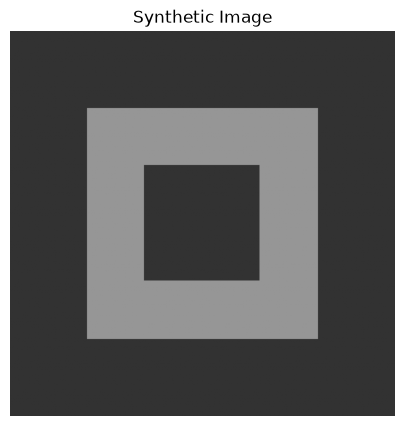

In [ ]:
# Display the image
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Synthetic Image")
plt.axis('off')
plt.show()

In [ ]:
def add_gaussian_noise(img, variance, seed=None):
    """
    Add Gaussian noise with given variance.
    Assumes image is in [0, 255]. Normalizes to [0, 1]
    """
    rng = np.random.default_rng(seed)

    # Normalize to [0, 1]
    img_norm = img / 255.0

    # Generate Gaussian noise: mean=0, std=sqrt(variance)
    sigma = np.sqrt(variance)
    noise = rng.normal(loc=0.0, scale=sigma, size=img.shape)

    # Add noise
    noisy = img_norm + noise

    # Clip back to [0, 1] to keep valid range, then scale to [0, 255]
    noisy = np.clip(noisy, 0, 1) * 255.0
    return noisy

img_low  = add_gaussian_noise(img, variance=0.005, seed=1)
img_high = add_gaussian_noise(img, variance=0.05,  seed=1)

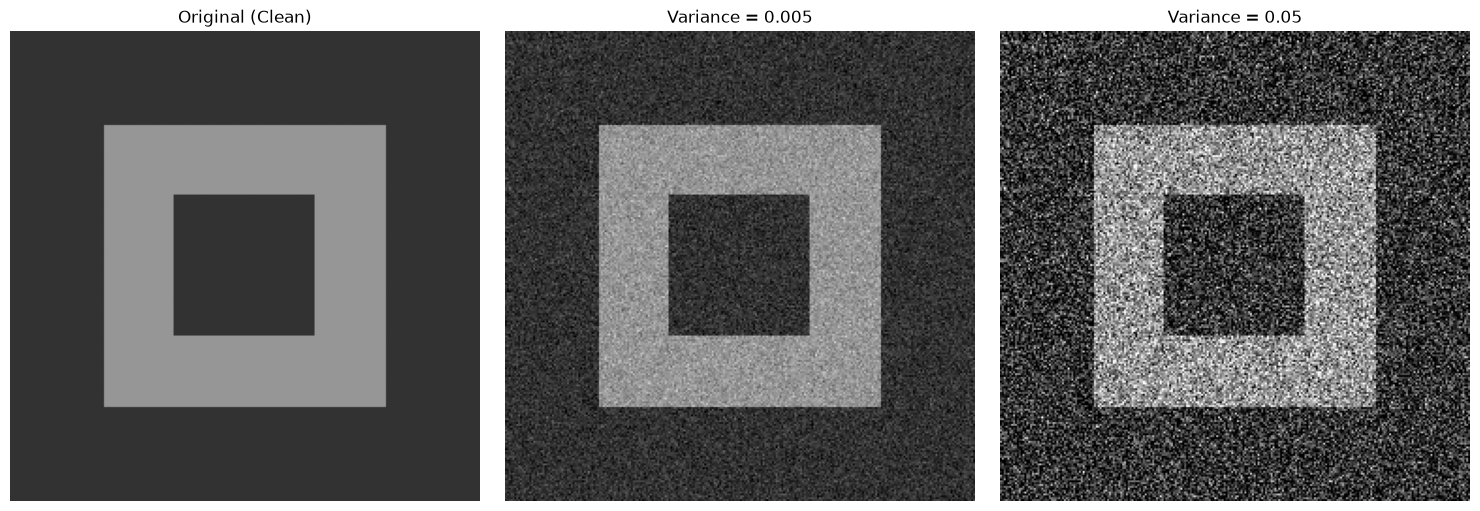

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original (Clean)")

axes[1].imshow(img_low, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Variance = 0.005")

axes[2].imshow(img_high, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Variance = 0.05")

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

2b) Apply LoG Filter with sigma of 0.5, 2, 4 and compute zero crossing.
Estimate the LoG filter with a DoG filter.

In [ ]:
# Apply LoG Filter with sigma of 0.5, 2, 4 and compute zero crossing
def make_log_2d(sigma, size=None):
    """2D Laplacian of Gaussian kernel."""
    if size is None:
        size = int(6 * sigma) | 1  # odd, ~6 sigma wide
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    r2 = xx**2 + yy**2
    log = ((r2 - 2 * sigma**2) / (sigma**4)) * np.exp(-r2 / (2 * sigma**2))
    log -= log.mean()  
    return log

def convolve2d_same(image, kernel):
    """2D convolution with 'same' output size."""
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode='reflect')
    out = np.zeros_like(image)
    for i in range(kh):
        for j in range(kw):
            out += kernel[i, j] * padded[i:i+image.shape[0], j:j+image.shape[1]]
    return out

def zero_crossing(LoG):
    """Find zero-crossings. Normalize first for stability."""
    scale = np.abs(LoG).max()
    if scale < 1e-12:
        return np.zeros_like(LoG, dtype=bool)
    L = LoG / scale
    zc = np.zeros_like(L, dtype=bool)
    for shift in [(0, 1), (1, 0), (1, 1), (1, -1)]:
        rolled = np.roll(np.roll(L, shift[0], axis=0), shift[1], axis=1)
        zc |= (L * rolled < 0)
    return zc

In [17]:
def normalize(x):
    m = np.abs(x).max()      # find the largest magnitude (either + or -)
    if m < 1e-12:
        return x             # avoid divide-by-zero for all-zero input
    return x / m 

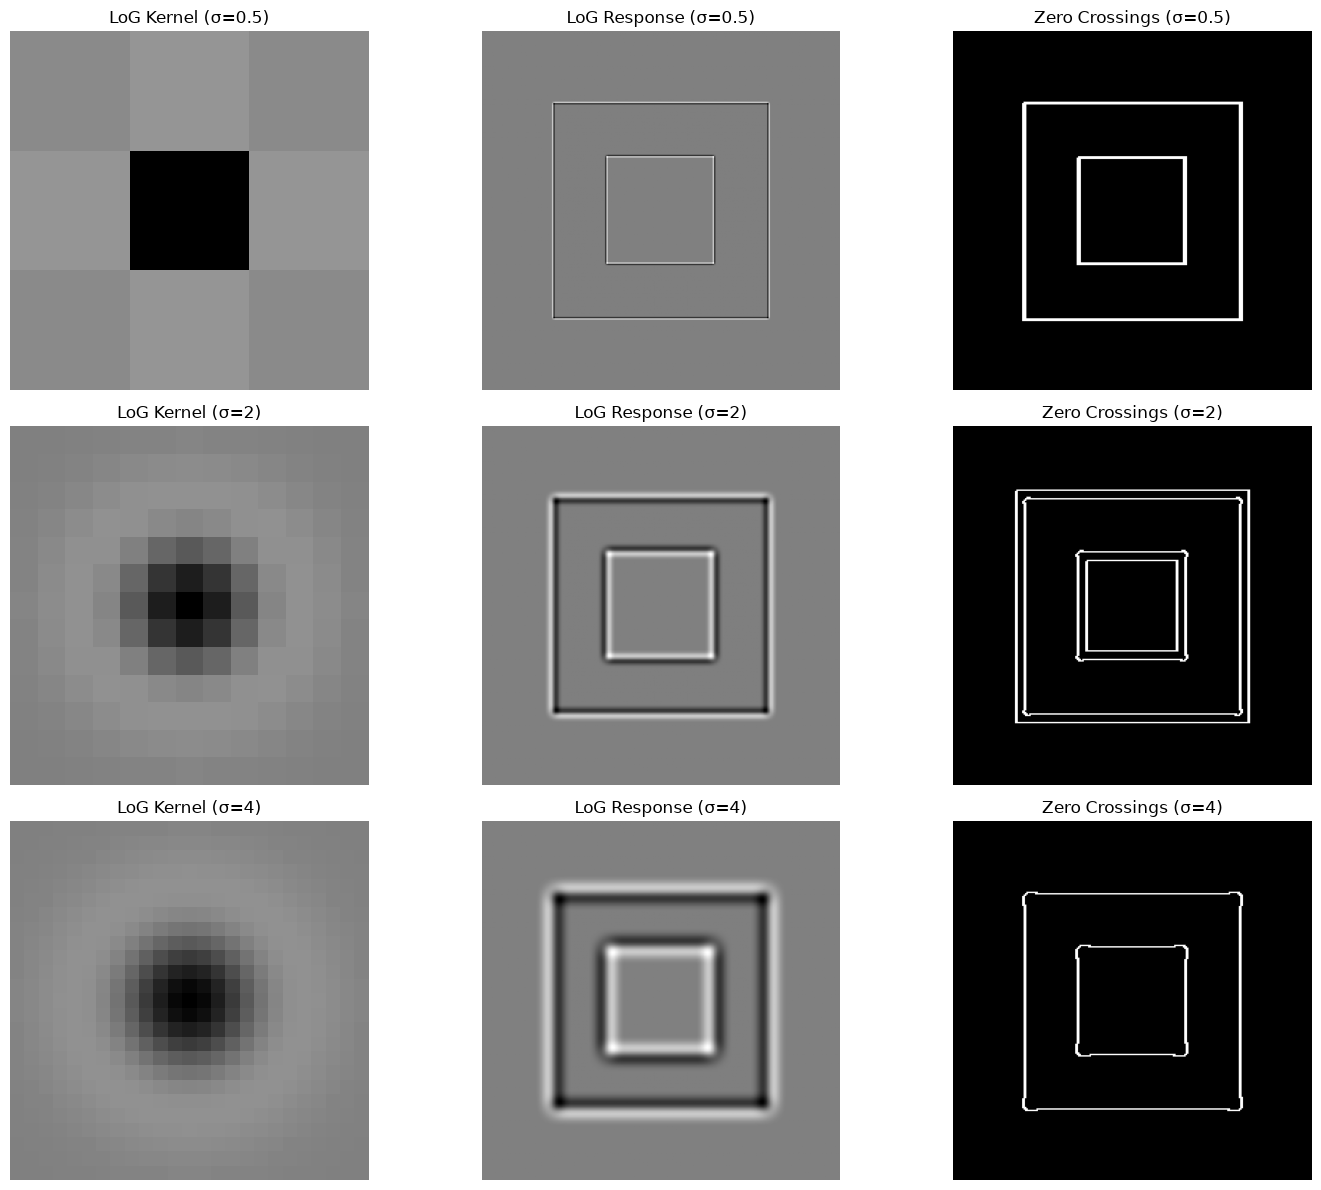

In [18]:
sigmas = [0.5, 2, 4]
fig, axes = plt.subplots(len(sigmas), 3, figsize=(15, 4 * len(sigmas)))

for i, sigma in enumerate(sigmas):
    kernel = make_log_2d(sigma)
    response = convolve2d_same(img_norm, kernel)
    zc = zero_crossing(response)

    # Normalize both kernel and response so 0 → mid-gray
    kernel_vis   = normalize(kernel)
    response_vis = normalize(response)

    # vmin/vmax symmetric so 0 maps to mid-gray
    axes[i, 0].imshow(kernel_vis, cmap='gray', vmin=-1, vmax=1)
    axes[i, 0].set_title(f'LoG Kernel (σ={sigma})')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(response_vis, cmap='gray', vmin=-1, vmax=1)
    axes[i, 1].set_title(f'LoG Response (σ={sigma})')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(zc, cmap='gray')
    axes[i, 2].set_title(f'Zero Crossings (σ={sigma})')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

In [20]:
def make_gaussian_2d(sigma, size=None):
    """2D Gaussian kernel."""
    if size is None:
        size = int(6 * sigma) | 1
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    g = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return g / g.sum()  # normalized to sum = 1

def make_dog_2d(sigma, k=1.6, size=None):
    """
    Difference of Gaussians kernel approximating LoG.
    DoG = G(k*sigma) - G(sigma)
    """
    sigma2 = k * sigma
    if size is None:
        size = int(6 * sigma2) | 1  # size based on the wider Gaussian
    # Make both at the SAME size so they can be subtracted
    g1 = make_gaussian_2d(sigma, size)
    g2 = make_gaussian_2d(sigma2, size)
    dog = g2 - g1
    return dog

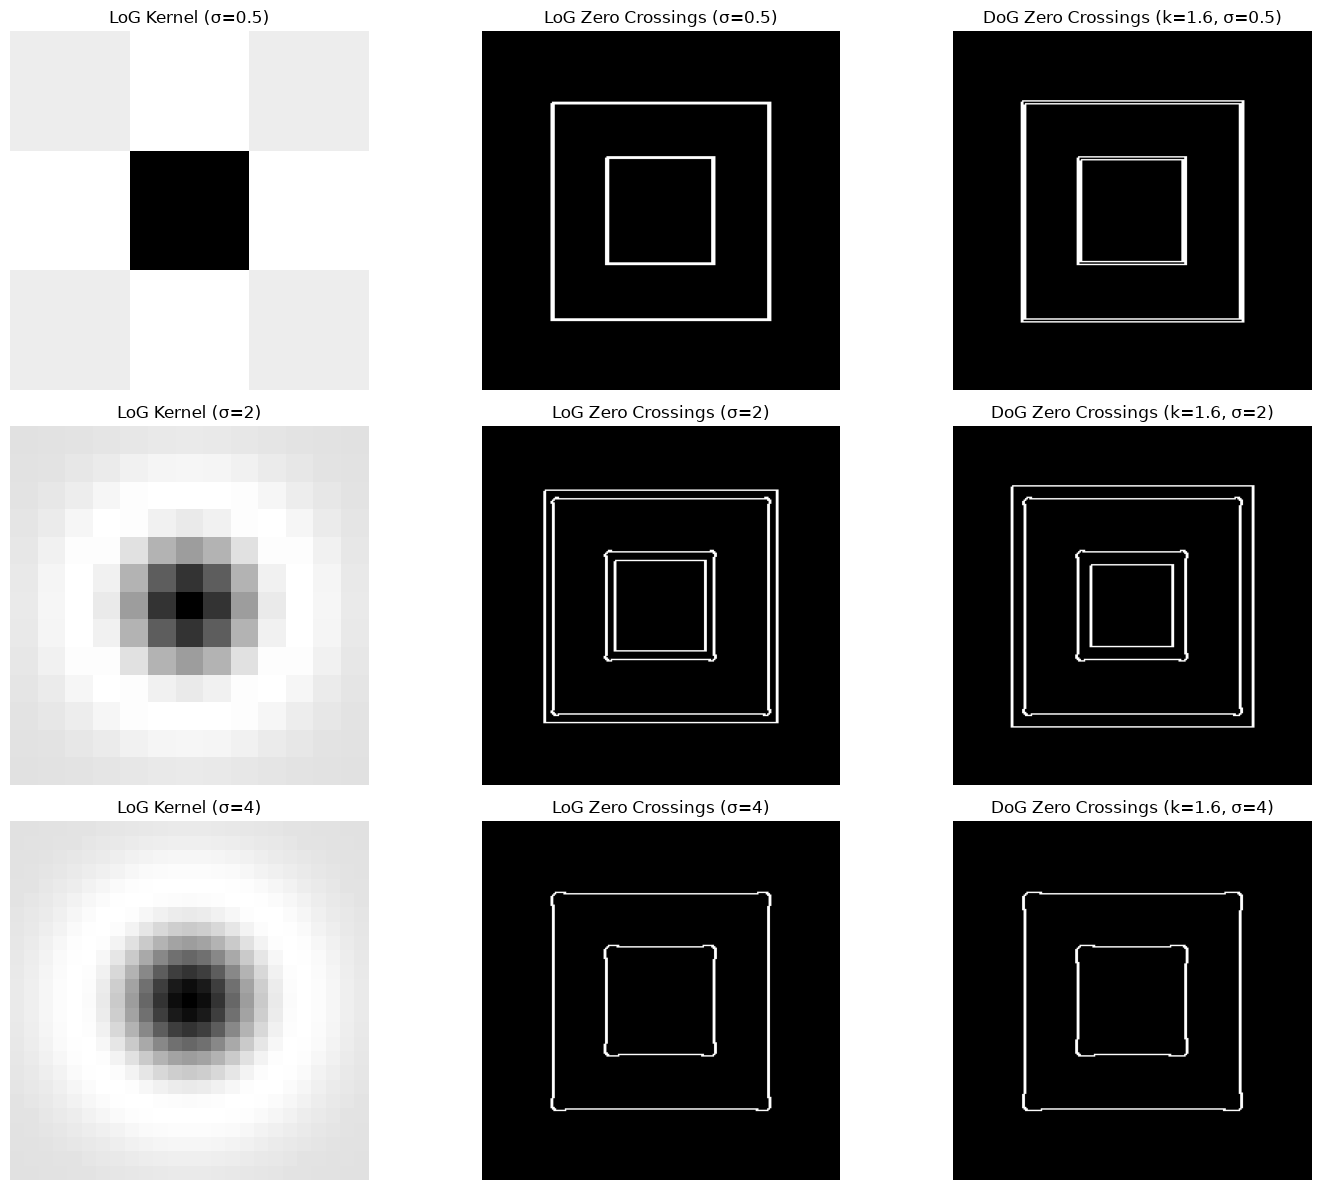

In [ ]:
k = 1.6  # sigma

fig, axes = plt.subplots(len(sigmas), 3, figsize=(15, 4 * len(sigmas)))

for i, sigma in enumerate(sigmas):
    # LoG
    log_kernel = make_log_2d(sigma)
    log_response = convolve2d_same(img_norm, log_kernel)
    log_zc = zero_crossing(log_response)

    # DoG
    dog_kernel = make_dog_2d(sigma, k=k)
    dog_response = convolve2d_same(img_norm, dog_kernel)
    dog_zc = zero_crossing(dog_response)

    # Normalize both
    log_vis = log_response / (np.abs(log_response).max() + 1e-12)
    dog_vis = dog_response / (np.abs(dog_response).max() + 1e-12)

    axes[i, 0].imshow(log_kernel, cmap='gray')
    axes[i, 0].set_title(f'LoG Kernel (σ={sigma})')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(log_zc, cmap='gray')
    axes[i, 1].set_title(f'LoG Zero Crossings (σ={sigma})')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(dog_zc, cmap='gray')
    axes[i, 2].set_title(f'DoG Zero Crossings (k={k}, σ={sigma})')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

2c) Compute and show the edge magnitude and direction for synthetic and corrupted images.
Study the edge direction along the square. Do you see the edge direction changing? Do you
see that the edge directions are antiparallel at the opposite sides of the square?

In [23]:
# ---- Load/create the three versions of the synthetic image ----
def make_synthetic(size=250):
    img = np.full((size, size), 50, dtype=np.float64)
    img[50:200, 50:200] = 150
    img[87:162, 87:162] = 50
    return img

def add_gaussian_noise(img, variance, seed=None):
    rng = np.random.default_rng(seed)
    img_norm = img / 255.0
    noise = rng.normal(0, np.sqrt(variance), img.shape)
    return np.clip(img_norm + noise, 0, 1) * 255.0

img_clean = make_synthetic()
img_low   = add_gaussian_noise(img_clean, 0.005, seed=1)
img_high  = add_gaussian_noise(img_clean, 0.05,  seed=1)

# ---- Kernels ----
def make_gaussian_1d(sigma, size=None):
    if size is None:
        size = int(6 * sigma) | 1
    x = np.arange(-(size // 2), size // 2 + 1)
    g = np.exp(-x**2 / (2 * sigma**2))
    g /= g.sum()
    return g

def make_gaussian_1d_d1(sigma, size=None):
    """1D first derivative of Gaussian."""
    if size is None:
        size = int(6 * sigma) | 1
    x = np.arange(-(size // 2), size // 2 + 1)
    g = np.exp(-x**2 / (2 * sigma**2))
    g /= g.sum()
    return -(x / sigma**2) * g

def convolve1d_axis(image, kernel, axis):
    """1D convolution along a specific axis."""
    n = len(kernel)
    pad = n // 2
    padded = np.pad(image, [(pad, pad) if i == axis else (0, 0)
                            for i in range(image.ndim)], mode='reflect')
    out = np.zeros_like(image)
    for i, k in enumerate(kernel):
        sl = [slice(None)] * image.ndim
        sl[axis] = slice(i, i + image.shape[axis])
        out += k * padded[tuple(sl)]
    return out

def gradient(image, sigma):
    """Compute Gx, Gy, magnitude, and direction using DoG."""
    g   = make_gaussian_1d(sigma)
    g_d = make_gaussian_1d_d1(sigma)

    # Gx: derivative along x, smoothing along y
    Gx = convolve1d_axis(convolve1d_axis(image, g_d, axis=1), g, axis=0)
    # Gy: derivative along y, smoothing along x
    Gy = convolve1d_axis(convolve1d_axis(image, g, axis=1), g_d, axis=0)

    mag = np.sqrt(Gx**2 + Gy**2)
    direction = np.arctan2(Gy, Gx)   # range (-π, π]
    return Gx, Gy, mag, direction

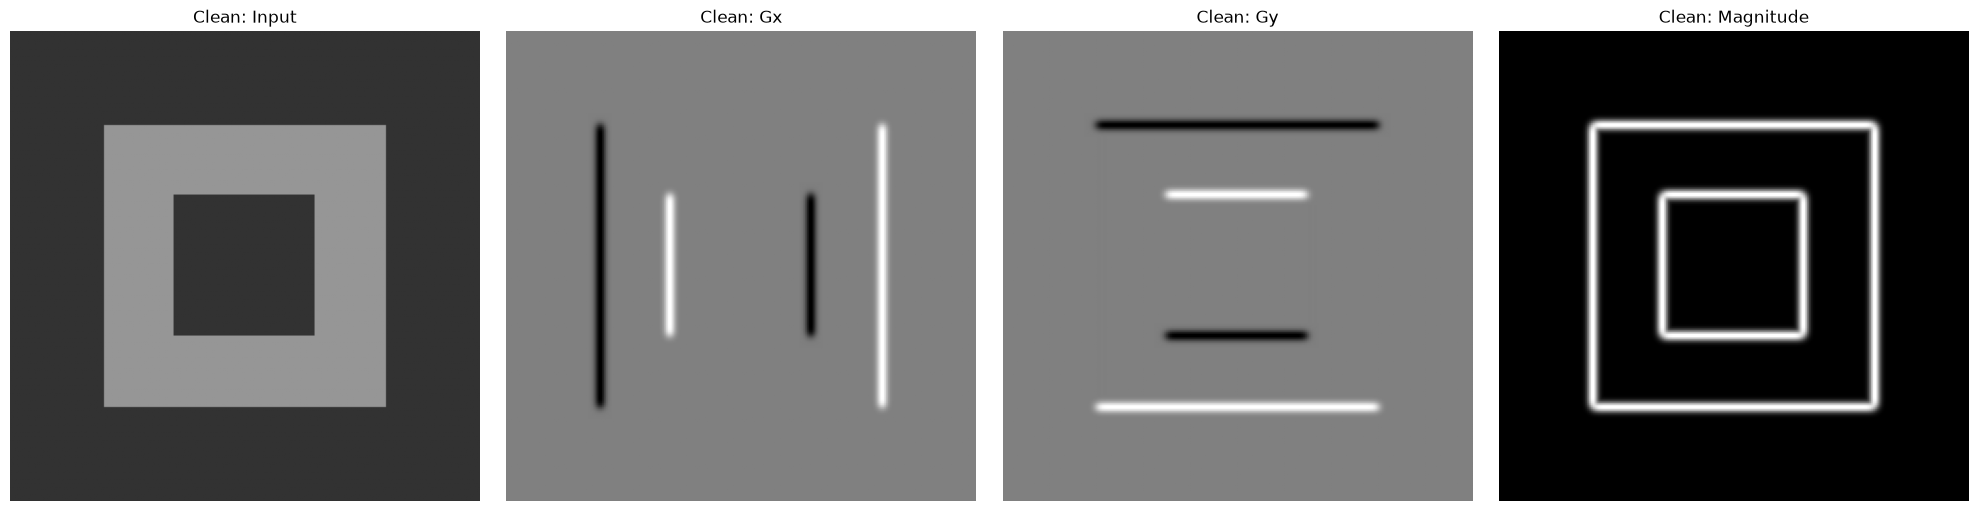

In [24]:
def show_edge_maps(img, sigma, title_prefix=""):
    Gx, Gy, mag, direction = gradient(img, sigma)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'{title_prefix}Input')

    axes[1].imshow(Gx, cmap='gray', vmin=-np.abs(Gx).max(), vmax=np.abs(Gx).max())
    axes[1].set_title(f'{title_prefix}Gx')

    axes[2].imshow(Gy, cmap='gray', vmin=-np.abs(Gy).max(), vmax=np.abs(Gy).max())
    axes[2].set_title(f'{title_prefix}Gy')

    # Magnitude — normalized so the largest edge = white
    axes[3].imshow(mag / mag.max(), cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f'{title_prefix}Magnitude')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Apply with sigma = 2 
show_edge_maps(img_clean, 2.0, "Clean: ")

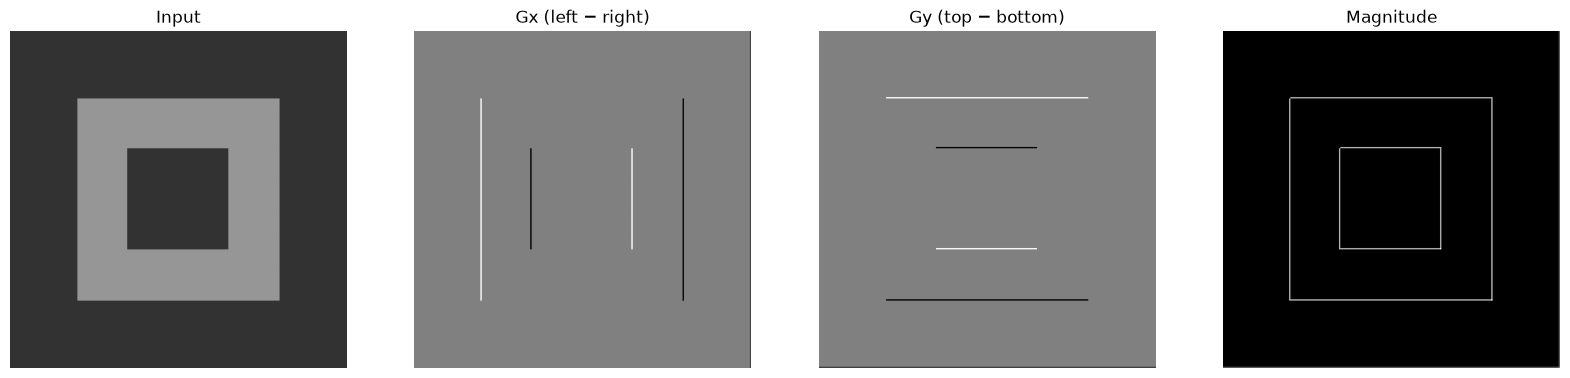

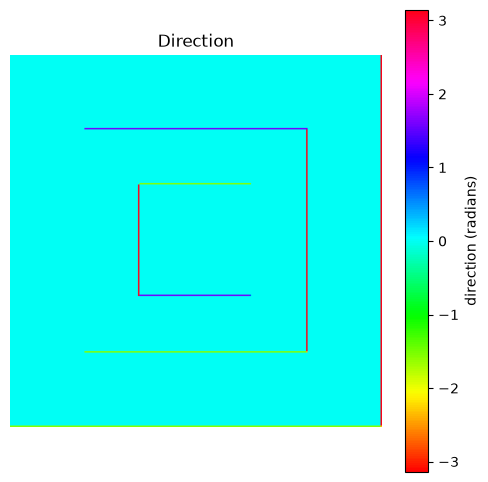

In [ ]:
# Loading image
img = np.full((250, 250), 50.0)
img[50:200, 50:200] = 150
img[87:162, 87:162] = 50

# 1D derivative kernels without Gaussian smoothing
dx = np.array([1, -1])   # horizontal difference
dy = np.array([1, -1])   # vertical difference

# Gx: subtract neighbors left-to-right
Gx = convolve1d(img, dx, axis=1, mode='constant')
# Gy: subtract neighbors top-to-bottom
Gy = convolve1d(img, dy, axis=0, mode='constant')

# Magnitude and direction
magnitude = np.sqrt(Gx**2 + Gy**2)
direction = np.arctan2(Gy, Gx)  # in radians

# Display
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255); axes[0].set_title("Input")
axes[1].imshow(Gx, cmap='gray'); axes[1].set_title("Gx (left − right)")
axes[2].imshow(Gy, cmap='gray'); axes[2].set_title("Gy (top − bottom)")
axes[3].imshow(magnitude, cmap='gray'); axes[3].set_title("Magnitude")
for ax in axes: ax.axis('off')
plt.show()

# Direction (using hsv so angle becomes color)
plt.figure(figsize=(6, 6))
plt.imshow(direction, cmap='hsv', vmin=-np.pi, vmax=np.pi)
plt.colorbar(label='direction (radians)')
plt.title("Direction")
plt.axis('off')
plt.show()